## Strategy Simulation

In [63]:
sns.set_style("white")
pastel_purple = '#c8b6e2'
pastel_green = '#a8d5c2'
pastel_dark_green = '#2d8659'

# Baseline metrics from the actual campaign
total_calls = len(df_clean)
total_subs = df_clean['y_binary'].sum()
baseline_rate = total_subs / total_calls * 100

In [64]:
# STRATEGY EVALUATION HELPER

def evaluate_strategy(name, mask, philosophy):
    """Apply a boolean mask to df_clean and return strategy metrics."""
    subset = df_clean[mask]
    n_calls = len(subset)
    n_subs = subset['y_binary'].sum()
    conv_rate = (n_subs / n_calls * 100) if n_calls > 0 else 0
    
    return {
        'strategy': name,
        'philosophy': philosophy,
        'calls': n_calls,
        'call_share_pct': round(n_calls / total_calls * 100, 2),
        'subscribers': int(n_subs),
        'conv_rate_pct': round(conv_rate, 2),
        'lift_vs_baseline': round(conv_rate / baseline_rate, 2),
        'calls_saved': total_calls - n_calls,
        'calls_saved_pct': round((1 - n_calls / total_calls) * 100, 2),
        'sub_coverage_pct': round(n_subs / total_subs * 100, 2),
        'subs_lost': int(total_subs - n_subs),
        'subs_lost_pct': round((1 - n_subs / total_subs) * 100, 2)
    }

In [65]:
# STRATEGY DEFINITIONS

results = []

# ----- STRATEGY 0 — BASELINE (the actual campaign) -----
mask_baseline = pd.Series([True] * len(df_clean), index=df_clean.index)
results.append(evaluate_strategy(
    name='S0 — Baseline (actual)',
    mask=mask_baseline,
    philosophy='Call everyone (status quo)'
))

# ----- STRATEGY 1 — ICP-ONLY (aggressive targeting) -----
mask_icp = (
    (df_clean['contact'] == 'cellular') &
    (df_clean['month'].isin(['mar', 'sep', 'oct', 'dec'])) &
    (df_clean['poutcome'].isin(['success', 'failure']))
)
results.append(evaluate_strategy(
    name='S1 — ICP Only',
    mask=mask_icp,
    philosophy='Maximum precision, minimum volume'
))

# ----- STRATEGY 2 — SMART FILTER (practical targeting) -----
# Cellular only + (previously contacted OR low-rate period) + cap on contacts
mask_smart = (
    (df_clean['contact'] == 'cellular') &
    ((df_clean['poutcome'].isin(['success', 'failure'])) | (df_clean['euribor3m'] < 2.0)) &
    (df_clean['campaign'] <= 3)
)
results.append(evaluate_strategy(
    name='S2 — Smart Filter',
    mask=mask_smart,
    philosophy='Balance volume and conversion'
))

# ----- STRATEGY 3 — CRISIS-AWARE (macro-driven) -----
# Call during low-rate periods only, plus basic channel filter
mask_crisis = (
    (df_clean['euribor3m'] < 2.0) &
    (df_clean['contact'] == 'cellular') &
    (df_clean['campaign'] <= 5)
)
results.append(evaluate_strategy(
    name='S3 — Crisis-Aware',
    mask=mask_crisis,
    philosophy='Calibrate to economic conditions'
))

# ----- STRATEGY 4 — DROP THE WORST (defensive trim) -----
# Keep everything except the explicitly bad segments
mask_drop_worst = ~(
    (df_clean['contact'] == 'telephone') &
    (df_clean['month'] == 'may') &
    (df_clean['job'].isin(['blue-collar', 'services', 'entrepreneur']))
)
results.append(evaluate_strategy(
    name='S4 — Drop DNC Segment',
    mask=mask_drop_worst,
    philosophy='Minimal change — eliminate the worst only'
))

# Build comparison table
strategy_df = pd.DataFrame(results)
print("STRATEGY COMPARISON")
display_cols = ['strategy', 'calls', 'call_share_pct', 'subscribers',
                'conv_rate_pct', 'lift_vs_baseline', 'sub_coverage_pct']
print(strategy_df[display_cols].to_string(index=False))

STRATEGY COMPARISON
              strategy  calls  call_share_pct  subscribers  conv_rate_pct  lift_vs_baseline  sub_coverage_pct
S0 — Baseline (actual)  41176          100.00         4639          11.27              1.00            100.00
         S1 — ICP Only    772            1.87          421          54.53              4.84              9.08
     S2 — Smart Filter  11254           27.33         2816          25.02              2.22             60.70
     S3 — Crisis-Aware  11652           28.30         2999          25.74              2.28             64.65
 S4 — Drop DNC Segment  37452           90.96         4508          12.04              1.07             97.18


In [66]:
# EFFICIENCY METRICS

print("EFFICIENCY COMPARISON")

efficiency_cols = ['strategy', 'calls_saved', 'calls_saved_pct',
                   'subs_lost', 'subs_lost_pct', 'conv_rate_pct']
print(strategy_df[efficiency_cols].to_string(index=False))

print("\nInterpretation guide:")
print("  - calls_saved_pct: how much call volume each strategy saves vs baseline")
print("  - subs_lost_pct:   how much of original subscriber base each strategy loses")
print("  - The ideal strategy maximizes calls_saved while minimizing subs_lost")

EFFICIENCY COMPARISON
              strategy  calls_saved  calls_saved_pct  subs_lost  subs_lost_pct  conv_rate_pct
S0 — Baseline (actual)            0             0.00          0           0.00          11.27
         S1 — ICP Only        40404            98.13       4218          90.92          54.53
     S2 — Smart Filter        29922            72.67       1823          39.30          25.02
     S3 — Crisis-Aware        29524            71.70       1640          35.35          25.74
 S4 — Drop DNC Segment         3724             9.04        131           2.82          12.04

Interpretation guide:
  - calls_saved_pct: how much call volume each strategy saves vs baseline
  - subs_lost_pct:   how much of original subscriber base each strategy loses
  - The ideal strategy maximizes calls_saved while minimizing subs_lost


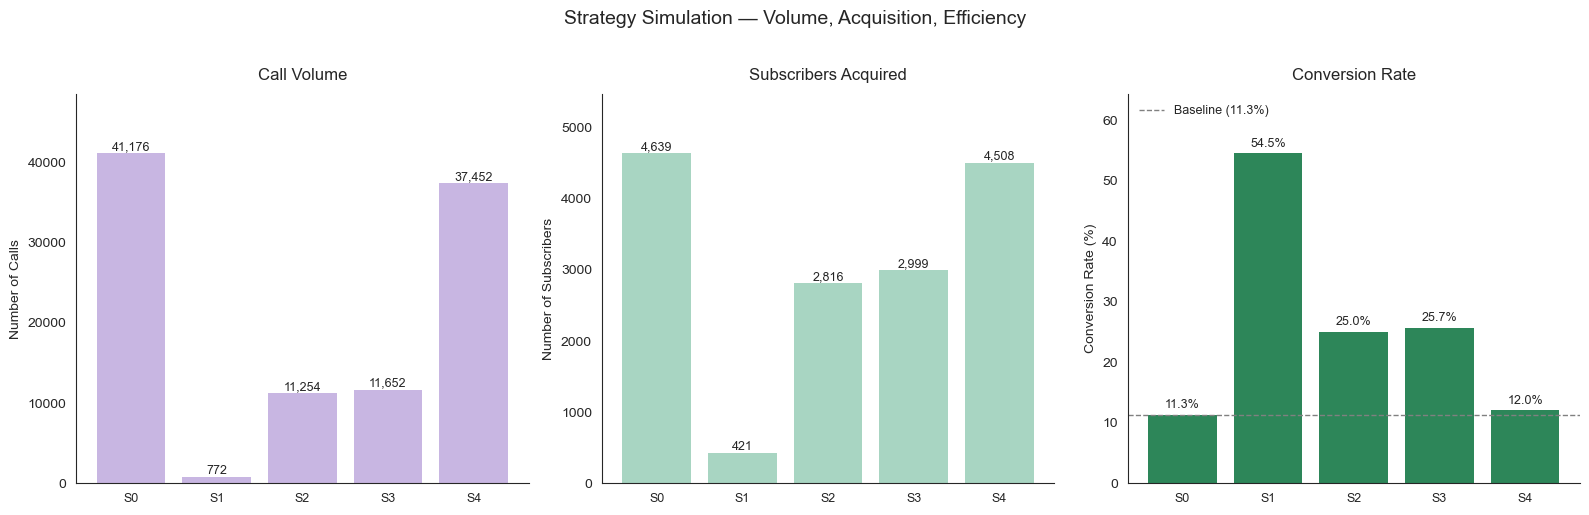

In [67]:
# STRATEGY COMPARISON VISUALIZATION

# Drop baseline from the plotting set so the bars show alternatives only
plot_df = strategy_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Call volume
axes[0].bar(range(len(plot_df)), plot_df['calls'],
            color=pastel_purple, edgecolor='none')
axes[0].set_title('Call Volume', fontsize=12, pad=10)
axes[0].set_ylabel('Number of Calls')
axes[0].set_xticks(range(len(plot_df)))
axes[0].set_xticklabels([s.split(' — ')[0] for s in plot_df['strategy']],
                         rotation=0, fontsize=9)
for i, v in enumerate(plot_df['calls']):
    axes[0].text(i, v + max(plot_df['calls'])*0.01, f'{int(v):,}',
                 ha='center', fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_ylim(0, max(plot_df['calls']) * 1.18)

# Chart 2: Subscribers acquired
axes[1].bar(range(len(plot_df)), plot_df['subscribers'],
            color=pastel_green, edgecolor='none')
axes[1].set_title('Subscribers Acquired', fontsize=12, pad=10)
axes[1].set_ylabel('Number of Subscribers')
axes[1].set_xticks(range(len(plot_df)))
axes[1].set_xticklabels([s.split(' — ')[0] for s in plot_df['strategy']],
                         rotation=0, fontsize=9)
for i, v in enumerate(plot_df['subscribers']):
    axes[1].text(i, v + max(plot_df['subscribers'])*0.01, f'{int(v):,}',
                 ha='center', fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_ylim(0, max(plot_df['subscribers']) * 1.18)

# Chart 3: Conversion rate
axes[2].bar(range(len(plot_df)), plot_df['conv_rate_pct'],
            color=pastel_dark_green, edgecolor='none')
axes[2].axhline(baseline_rate, color='gray', linestyle='--', linewidth=1,
                label=f'Baseline ({baseline_rate:.1f}%)')
axes[2].set_title('Conversion Rate', fontsize=12, pad=10)
axes[2].set_ylabel('Conversion Rate (%)')
axes[2].set_xticks(range(len(plot_df)))
axes[2].set_xticklabels([s.split(' — ')[0] for s in plot_df['strategy']],
                         rotation=0, fontsize=9)
for i, v in enumerate(plot_df['conv_rate_pct']):
    axes[2].text(i, v + max(plot_df['conv_rate_pct'])*0.02, f'{v:.1f}%',
                 ha='center', fontsize=9)
axes[2].legend(frameon=False, loc='upper left', fontsize=9)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].set_ylim(0, max(plot_df['conv_rate_pct']) * 1.18)

plt.suptitle('Strategy Simulation — Volume, Acquisition, Efficiency',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

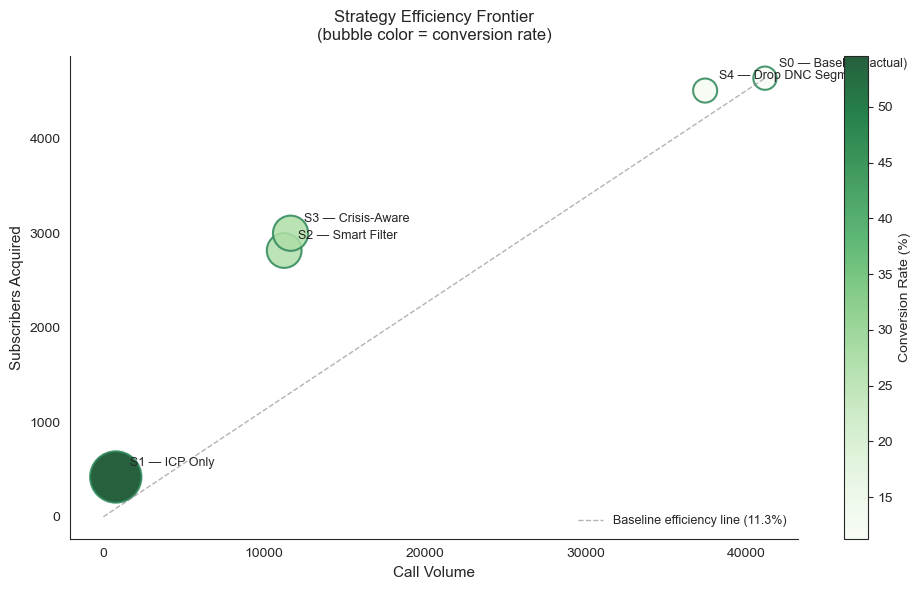

In [68]:
# EFFICIENCY FRONTIER — CALLS vs SUBSCRIBERS

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(strategy_df['calls'], strategy_df['subscribers'],
                     s=strategy_df['conv_rate_pct'] * 25,
                     c=strategy_df['conv_rate_pct'],
                     cmap='Greens', alpha=0.85,
                     edgecolors=pastel_dark_green, linewidth=1.5)

# Label each strategy
for _, row in strategy_df.iterrows():
    ax.annotate(row['strategy'],
                xy=(row['calls'], row['subscribers']),
                xytext=(10, 8), textcoords='offset points',
                fontsize=9)

# Reference: baseline efficiency line (calls × baseline rate)
ax.plot([0, total_calls], [0, total_subs],
        color='gray', linestyle='--', linewidth=1, alpha=0.6,
        label=f'Baseline efficiency line ({baseline_rate:.1f}%)')

ax.set_xlabel('Call Volume', fontsize=11)
ax.set_ylabel('Subscribers Acquired', fontsize=11)
ax.set_title('Strategy Efficiency Frontier\n(bubble color = conversion rate)',
             fontsize=12, pad=12)
ax.legend(frameon=False, loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.colorbar(scatter, label='Conversion Rate (%)')
plt.tight_layout()
plt.show()

In [69]:
# HEADLINE STATEMENTS

print("HEADLINE STATEMENTS PER STRATEGY")

for _, row in strategy_df.iterrows():
    if row['strategy'].startswith('S0'):
        continue
    print(f"\n{row['strategy']}")
    print(f"  Philosophy: {row['philosophy']}")
    print(f"  → Made {row['calls']:,} calls ({row['call_share_pct']}% of baseline)")
    print(f"  → Acquired {row['subscribers']:,} subscribers ({row['sub_coverage_pct']}% of baseline)")
    print(f"  → Conversion rate: {row['conv_rate_pct']}% ({row['lift_vs_baseline']}x baseline)")
    print(f"  → Saved {row['calls_saved']:,} calls ({row['calls_saved_pct']}%)")
    print(f"  → Lost {row['subs_lost']:,} subscribers ({row['subs_lost_pct']}%)")

HEADLINE STATEMENTS PER STRATEGY

S1 — ICP Only
  Philosophy: Maximum precision, minimum volume
  → Made 772 calls (1.87% of baseline)
  → Acquired 421 subscribers (9.08% of baseline)
  → Conversion rate: 54.53% (4.84x baseline)
  → Saved 40,404 calls (98.13%)
  → Lost 4,218 subscribers (90.92%)

S2 — Smart Filter
  Philosophy: Balance volume and conversion
  → Made 11,254 calls (27.33% of baseline)
  → Acquired 2,816 subscribers (60.7% of baseline)
  → Conversion rate: 25.02% (2.22x baseline)
  → Saved 29,922 calls (72.67%)
  → Lost 1,823 subscribers (39.3%)

S3 — Crisis-Aware
  Philosophy: Calibrate to economic conditions
  → Made 11,652 calls (28.3% of baseline)
  → Acquired 2,999 subscribers (64.65% of baseline)
  → Conversion rate: 25.74% (2.28x baseline)
  → Saved 29,524 calls (71.7%)
  → Lost 1,640 subscribers (35.35%)

S4 — Drop DNC Segment
  Philosophy: Minimal change — eliminate the worst only
  → Made 37,452 calls (90.96% of baseline)
  → Acquired 4,508 subscribers (97.18% o

Simulated four alternative targeting strategies against the actual campaign baseline by retroactively filtering the dataset. Each strategy represents a different operational philosophy and produces concrete numbers on call volume, subscriber acquisition, and conversion rate.

#### Results:

| Strategy | Philosophy | Calls | Subs | Conv Rate | Lift | Calls Saved | Subs Lost |
|----------|------------|------:|-----:|----------:|-----:|------------:|----------:|
| S0 Baseline | Status quo | 41,176 | 4,639 | 11.27% | 1.00x | — | — |
| S1 ICP Only | Maximum precision | 772 | 421 | **54.53%** | 4.84x | -98% | -91% |
| S2 Smart Filter | Segment-based balance | 11,254 | 2,816 | 25.02% | 2.22x | -73% | -39% |
| **S3 Crisis-Aware** | **Macro-driven balance** | **11,652** | **2,999** | **25.74%** | **2.28x** | **-72%** | **-35%** |
| S4 Drop DNC | Defensive trim | 37,452 | 4,508 | 12.04% | 1.07x | -9% | -3% |

#### Key Findings:

- **S3 (Crisis-Aware) dominates S2 (Smart Filter) on every dimension.** Both strategies use roughly the same call budget (~11,500 calls), but the macro-driven strategy captures 65% of subscribers vs 61%, with a slightly higher conversion rate (25.7% vs 25.0%) and the lowest subscriber loss among all volume-cutting strategies. This validates the Step 5 reframe: **interest rate environment is a stronger lever than customer segmentation.**
- **S1 (ICP Only) defines the upper bound of pure targeting.** A 54.5% conversion rate proves the ceiling of what precision targeting can achieve, but the strategy is impractical as a standalone approach — it captures only 9% of subscribers because the high-conversion pool is small.
- **S4 (Drop DNC) is the "no-regrets" minimum change.** Eliminating the bottom-performing telephone-May-blue-collar segment saves 9% of calls while losing only 3% of subscribers — a 27:1 cost-benefit ratio. This recommendation requires no operational changes beyond a single exclusion rule and is risk-free.

#### The Headline Statement:

Under the **Crisis-Aware strategy**, the bank could have acquired **65% of its subscribers using 28% of its call volume** — a **2.28x improvement in conversion efficiency** and a **72% reduction in call effort.** Translated to operational terms: 4 out of every 10 subscribers would have been retained while 7 out of every 10 calls would have been saved.

#### Recommended Strategy: Layered Approach

Rather than choosing one strategy, the recommended approach is layered:

1. **Adopt S4 immediately as a no-cost safety net** — eliminate the DNC segment as an unconditional rule. Zero risk, immediate efficiency gain.
2. **Adopt S3 as the primary targeting framework** — calibrate call volume to interest rate conditions. Major efficiency gain at modest subscriber cost.
3. **Reserve S1 (ICP) as a high-priority tier** — within the S3 strategy, prioritize ICP-matching clients first as the highest-value contacts.

#### Caveats:

- These are *retrospective simulations*, not forecasts. They show what the bank could have achieved with the same client pool if it had filtered differently. They do not account for opportunity cost (clients the bank might have acquired by calling more aggressively in low-rate periods) or operational changes that scaling up calling under low-rate conditions would entail.
- The 35% subscriber loss in S3 is real and would need to be acknowledged in any business case — the strategy trades acquisition volume for efficiency, not the other way around.
- The simulations assume the bank could perfectly predict which clients fall into each segment in real time. In practice, some segment definitions (especially `poutcome`) require historical data that wouldn't be available for fresh leads.